### Vanishing Gradient Problem
#### Definition
The **Vanishing Gradient Problem** occurs when gradients become extremely small as they are propagated backward through a deep neural network.

Result:
```
Tiny Gradients
      ↓
Tiny Weight Updates
      ↓
Little or No Learning
```

### Why Does It Happen?
Recall Backpropagation:
```
Loss
  ↑
Layer 4
  ↑
Layer 3
  ↑
Layer 2
  ↑
Layer 1
```

Gradients flow from:
```
Output Layer
      ↓
Input Layer
```
during the backward pass.

### Intuition
Suppose the gradient at each layer is:
```
0.5
```
Backpropagation multiplies gradients repeatedly.

#### Example:
```
0.5 × 0.5 × 0.5 × 0.5
```

Result:
```
0.0625
```

Add more layers:
```
0.5¹⁰
```

Result:

```text
0.000976
```
Almost zero.

### Visual Representation
```
Output Layer
Gradient = 1.0
      

Layer 4
Gradient = 0.5
      

Layer 3
Gradient = 0.25
      

Layer 2
Gradient = 0.125
      

Layer 1
Gradient = 0.0625
```

By the time the gradient reaches early layers:
```
Almost Zero
```

### Why Is This Bad?
Weight update rule:
```
w = w - lr × gradient
```

Suppose:
```
Gradient = 0.0000001
```

Update becomes:
```
Almost Nothing
```

Result:
```
Weights Stop Learning
```

### Which Layers Suffer Most?
The earliest layers.

**Diagram:**
```
Input
 ↓
Layer 1  ← Worst Affected
 ↓
Layer 2
 ↓
Layer 3
 ↓
Output
```

Output layers still receive strong gradients.

Input-side layers barely learn.

### Major Cause #1: Sigmoid Activation
Sigmoid output:
```
0 → 1
```

**Graph:**

![Sigmoid Activation Function.png](<attachment:Sigmoid Activation Function.png>)


At extreme values:
* Very Positive
* Very Negative

the curve becomes flat.

Flat curve means:
```
Gradient ≈ 0
```

During backpropagation:
```
Near-Zero
× Near-Zero
× Near-Zero
× Near-Zero
```

Eventually:
```
Gradient ≈ 0
```

### Major Cause #2: Tanh
Tanh is better than Sigmoid but still suffers from the same issue.

**Graph:**

![Tanh Activation Function.png](<attachment:Tanh Activation Function.png>)

At both ends:
```
Gradient becomes tiny
```

### Symptoms During Training
#### Loss Doesn't Improve
```
Epoch 1  Loss = 0.85
Epoch 50 Loss = 0.84
Epoch 100 Loss = 0.84
```

#### Training Very Slow
```
Thousands of epochs
Little progress
```

#### Early Layers Don't Learn
```
Weights barely change.
```

### Historical Impact
Early researchers tried:
```
10
20
30
Layer Networks
```

and training often failed.

This led many people to believe:
```
Deep Networks Don't Work
```

for several years.

### Solution #1: ReLU
ReLU:
```
ReLU(x) = max(0,x)
```

**Graph:**

![ReLU Activation Function.png](<attachment:ReLU Activation Function.png>)

For positive values:
```
Gradient = 1
```

instead of:
```
Gradient ≈ 0
```
This was one of the biggest breakthroughs in Deep Learning.

### Solution #2: Proper Weight Initialization
Use:
```
He Initialization
```

with ReLU.

This helps maintain healthy signal flow across layers.

### Solution #3: Batch Normalization
Later topic.

Concept:
```
Normalize Activations
      ↓
More Stable Gradients
```

### Solution #4: Residual Connections
Used heavily in modern architectures.

#### Diagram:

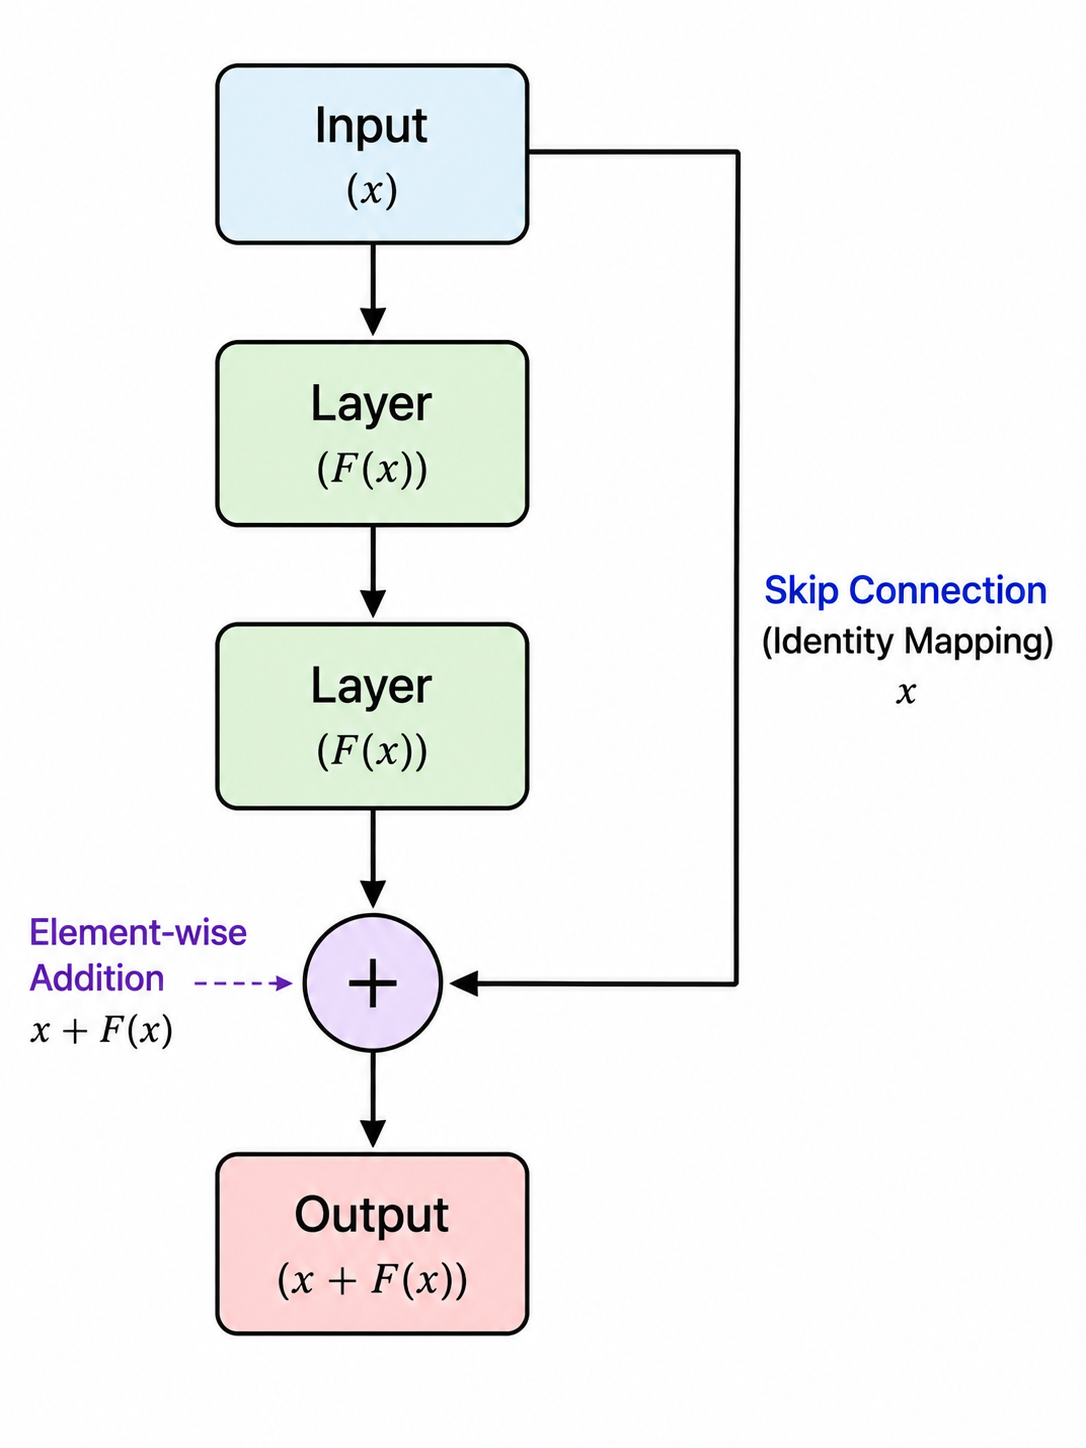

The shortcut helps gradients travel through deep networks.

Used in:
* ResNet
* Transformers
* GPT
* BERT
* LLaMA


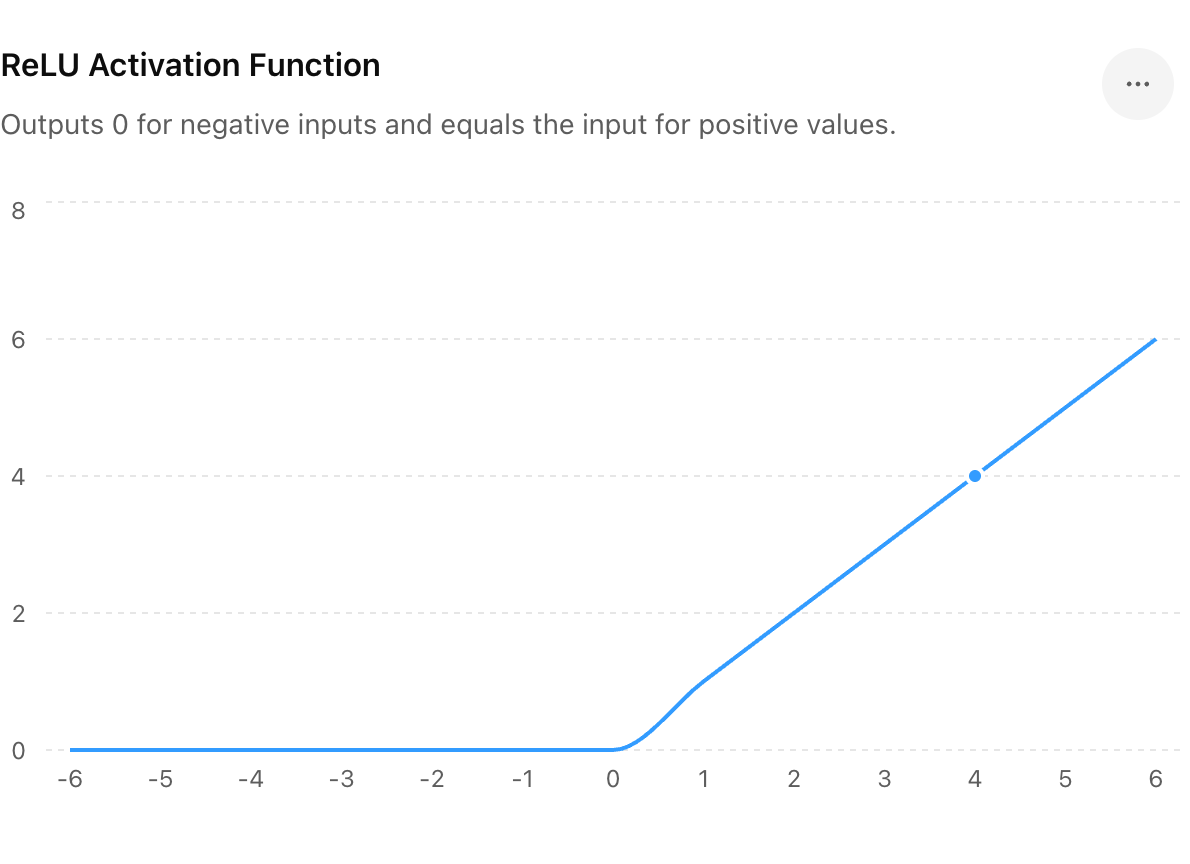
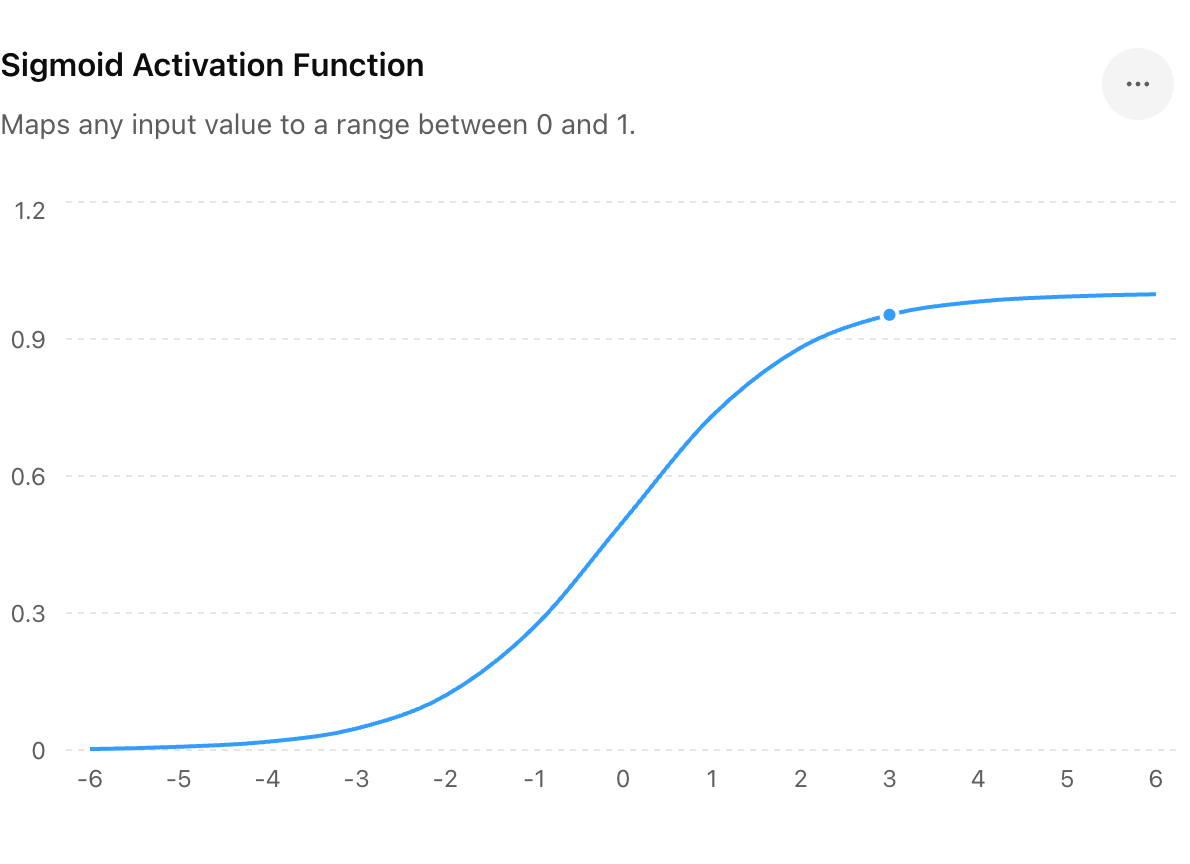
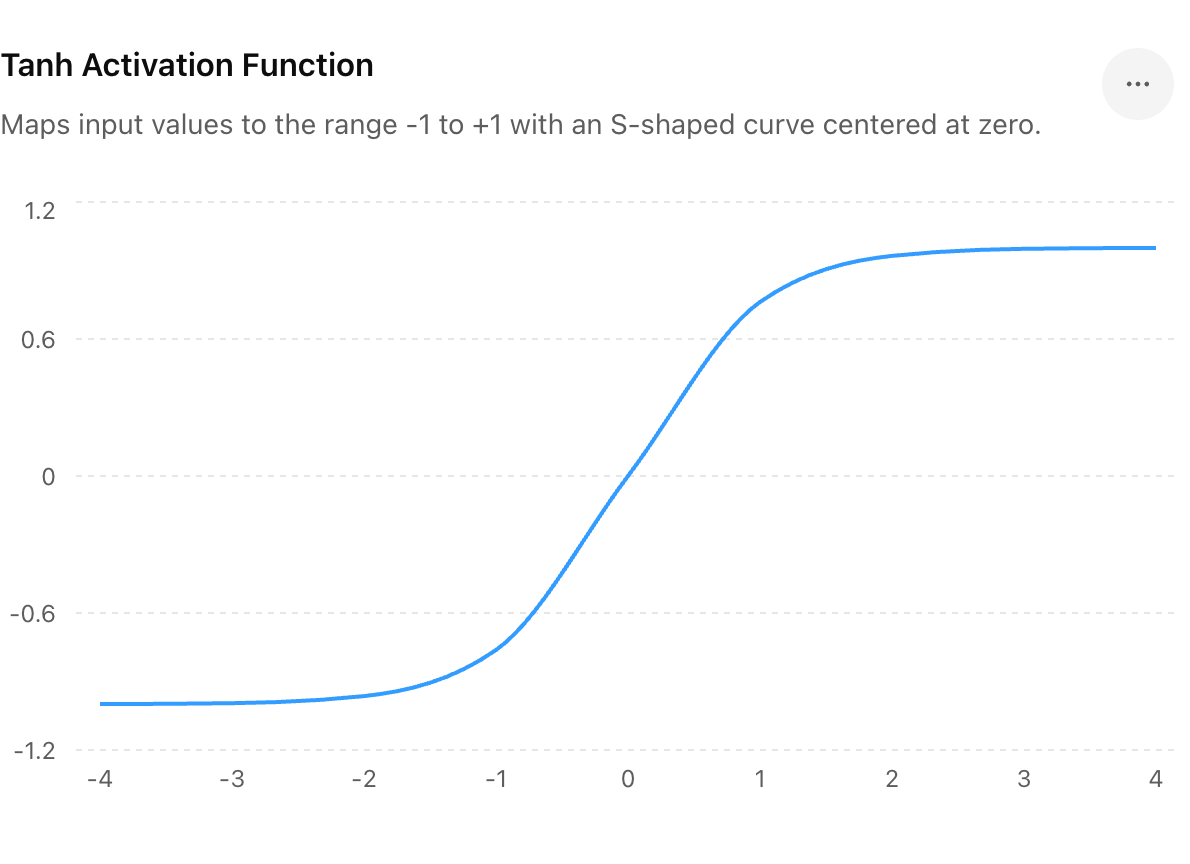